In [4]:
%pip install pytorch_forecasting fastparquet mlflow

Note: you may need to restart the kernel to use updated packages.


In [5]:

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import torch
import lightning as L

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.data.examples import get_stallion_data
from pytorch_forecasting.metrics import QuantileLoss

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

SEED =1
np.random.seed(SEED)
torch.manual_seed(SEED)
L.seed_everything(SEED)


def mae(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs(y_true - y_pred))


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denominator = np.maximum(np.abs(y_true), 1e-6)
    return np.mean(np.abs((y_true - y_pred) / denominator)) * 100


/Users/grigo/gits/seminars/gfu/ML_Zeitreihen/src_live/.venv/lib/python3.12/site-packages/pytorch_forecasting/models/base/_base_model.py:30: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
Seed set to 1


- Absatzdaten für die Getränkeproduktion
- agency + sku - statischen Kovariaten 
- 48 Zeitreihen mit voller Historie von 60 Monaten 

In [6]:
raw_df = get_stallion_data().copy()
raw_df["agency"] = raw_df["agency"].astype(str)
raw_df["sku"] = raw_df["sku"].astype(str)
raw_df["date"] = pd.to_datetime(raw_df["date"])
raw_df["time_idx"] = raw_df["date"].dt.year * 12 + raw_df["date"].dt.month
raw_df["time_idx"] -= raw_df["time_idx"].min()
raw_df["month"] = raw_df["date"].dt.strftime("%m")

series_summary = (
    raw_df.groupby(["agency", "sku"], observed=True)["volume"]
    .agg(n_obs="size", mean_volume="mean")
    .reset_index()
)
selected_series = (
    series_summary.query("n_obs == 60")
    .sort_values("mean_volume", ascending=False)
    .head(48)
    .copy()
)
selected_series["series_id"] = selected_series["agency"] + "_" + selected_series["sku"]

model_df = raw_df.merge(
    selected_series[["agency", "sku"]],
    on=["agency", "sku"],
    how="inner",
).copy()
model_df["series_id"] = model_df["agency"] + "_" + model_df["sku"]
model_df = model_df.sort_values(["series_id", "date"]).reset_index(drop=True)
focus_series_id = selected_series.iloc[0]["series_id"]
plot_series = selected_series["series_id"].head(4).tolist()
focus_df = model_df[model_df["series_id"] == focus_series_id].copy().reset_index(drop=True)

print("Raw dataset shape:", raw_df.shape)
print("Model subset shape:", model_df.shape)
print("Date range:", model_df["date"].min().date(), "bis", model_df["date"].max().date())
print("Anzahl Reihen im Modell-Subset:", model_df["series_id"].nunique())

selected_series[["agency", "sku", "series_id", "mean_volume"]].head(10)

Raw dataset shape: (21000, 28)
Model subset shape: (2880, 29)
Date range: 2013-01-01 bis 2017-12-01
Anzahl Reihen im Modell-Subset: 48


,agency,sku,series_id,mean_volume
8,Agency_02,SKU_03,Agency_02_SKU_03,14766.299647
278,Agency_50,SKU_02,Agency_50_SKU_02,12647.808475
26,Agency_05,SKU_01,Agency_05_SKU_01,12595.021300
343,Agency_60,SKU_01,Agency_60_SKU_01,11752.066850
66,Agency_12,SKU_01,Agency_12_SKU_01,11622.589450
108,Agency_20,SKU_02,Agency_20_SKU_02,11400.021225
174,Agency_30,SKU_03,Agency_30_SKU_03,11337.631162
271,Agency_49,SKU_03,Agency_49_SKU_03,10480.216562
17,Agency_03,SKU_03,Agency_03_SKU_03,10183.428543
205,Agency_38,SKU_01,Agency_38_SKU_01,10159.952450


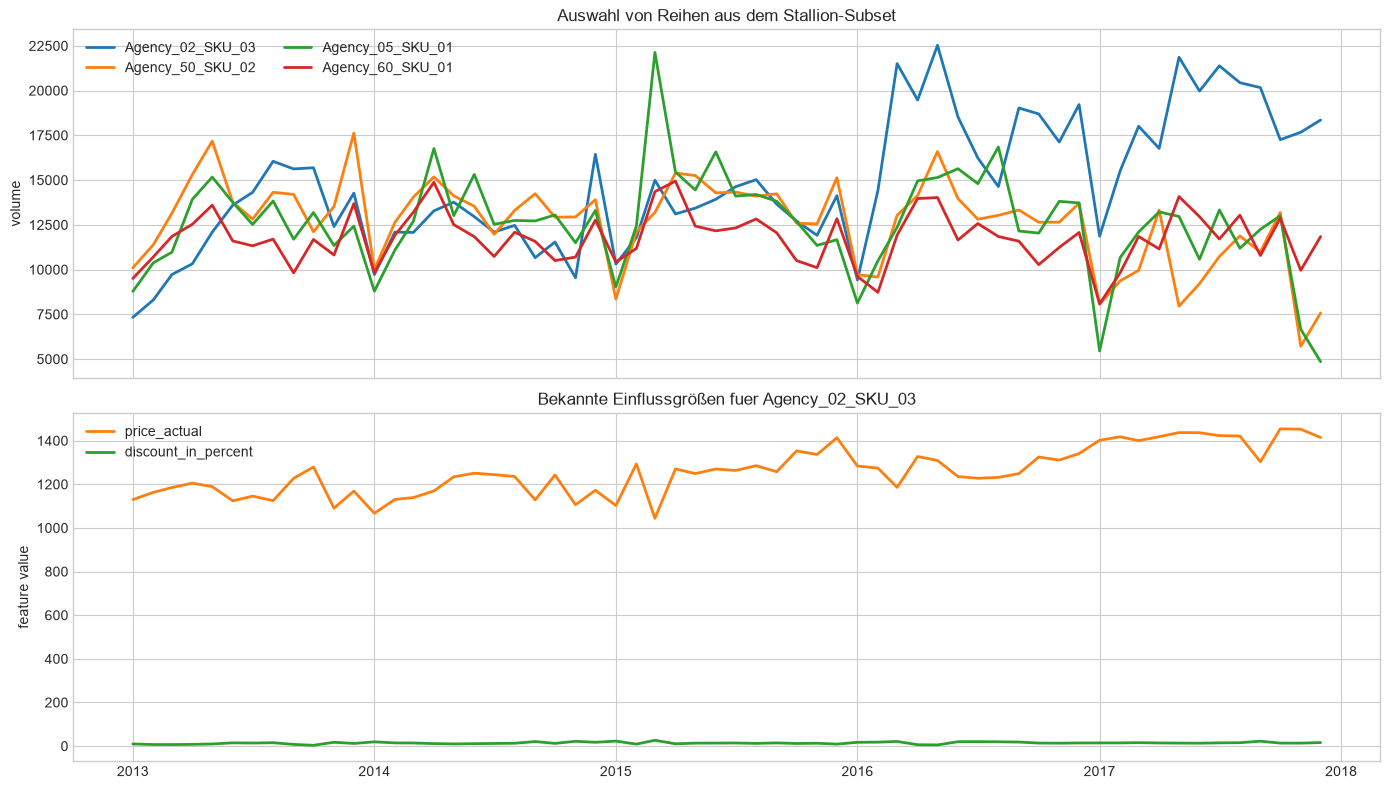

In [7]:

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for series_id in plot_series:
    subset = model_df[model_df["series_id"] == series_id]
    axes[0].plot(subset["date"], subset["volume"], linewidth=2, label=series_id)

axes[0].set_title("Auswahl von Reihen aus dem Stallion-Subset")
axes[0].set_ylabel("volume")
axes[0].legend(ncol=2)

axes[1].plot(focus_df["date"], focus_df["price_actual"], linewidth=2, color="tab:orange", label="price_actual")
axes[1].plot(
    focus_df["date"],
    focus_df["discount_in_percent"],
    linewidth=2,
    color="tab:green",
    label="discount_in_percent",
)
axes[1].set_title(f"Bekannte Einflussgrößen fuer {focus_series_id}")
axes[1].set_ylabel("feature value")
axes[1].legend()

plt.tight_layout()
plt.show()


In [8]:

encoder_length = 24 # Model sieht 24 Zeitschritte zurück 
prediction_length = 6 # Wir sagen 6 Zeitschritte voraus 

known_real_cols = [ # bekannte Eingänge zur Vorhersagezeit bekannt 
    "time_idx",
    "price_actual", # Plan
    "discount_in_percent", # Plan
    "industry_volume", # Branchenprognosen / Marktdaten / Wetter 
    "soda_volume", # Ähnlicher Markt
    "avg_max_temp", # Wetter 
    "christmas", # Feiertage 
    "new_year",
    "easter_day",
]

training_cutoff = model_df["time_idx"].max() - prediction_length # letzer Encoder-Block + 6 Schritte als Ziel 

training = TimeSeriesDataSet(
    model_df[model_df["time_idx"] <= training_cutoff],
    time_idx="time_idx",
    target="volume",
    group_ids=["agency", "sku"],
    min_encoder_length=encoder_length,
    max_encoder_length=encoder_length,
    min_prediction_length=prediction_length,
    max_prediction_length=prediction_length,
    static_categoricals=["agency", "sku"], # konstant für jede einzelne  Zeitreihe 
    time_varying_known_reals=known_real_cols, # numerisch, auch in der Zukunft bekannt 
    time_varying_known_categoricals=["month"], # kategorisch, auch in der Zukunft bekannt  
    time_varying_unknown_reals=["volume"], # unbekannt = das Ziel selbst 
    target_normalizer=GroupNormalizer(groups=["agency", "sku"], transformation="softplus"), # Normalisierung pro Gruppe + Transformation 
    add_relative_time_idx=True,
    add_target_scales=True, # Mittelwert und Standardabw. für Zielvariablen 
    add_encoder_length=True,
)


validation = TimeSeriesDataSet.from_dataset(
    training,
    model_df,
    predict=True,
    stop_randomization=True,
)

train_tft_loader = training.to_dataloader(train=True, batch_size=64, num_workers=0)
val_tft_loader = validation.to_dataloader(train=False, batch_size=128, num_workers=0)

batch_x, batch_y = next(iter(train_tft_loader))
pd.Series(
    {
        "encoder_cont": tuple(batch_x["encoder_cont"].shape),
        "decoder_cont": tuple(batch_x["decoder_cont"].shape),
        "encoder_cat": tuple(batch_x["encoder_cat"].shape),
        "decoder_cat": tuple(batch_x["decoder_cat"].shape),
        "target_tensor": tuple(batch_y[0].shape),
        "training_cutoff": int(training_cutoff),
    }
)

encoder_cont       (64, 24, 14)
decoder_cont        (64, 6, 14)
encoder_cat         (64, 24, 3)
decoder_cat          (64, 6, 3)
target_tensor           (64, 6)
training_cutoff              53
dtype: object

In [9]:
import mlflow

# ── Hyperparameter ─────────────────────────────────────────────────────────────
hidden_size            = 16
attention_head_size    = 4
dropout                = 0.1
hidden_continuous_size = 8
learning_rate          = 0.03
max_epochs             = 40
mlflow.set_tracking_uri("http://localhost:5007")

# ── MLflow Run starten ─────────────────────────────────────────────────────────
mlflow.set_experiment("TFT_stallion")
mlflow.start_run(run_name=f"tft_h{hidden_size}_ep{max_epochs}")
mlflow.log_params({
    "encoder_length":         encoder_length,
    "prediction_length":      prediction_length,
    "hidden_size":            hidden_size,
    "attention_head_size":    attention_head_size,
    "dropout":                dropout,
    "hidden_continuous_size": hidden_continuous_size,
    "learning_rate":          learning_rate,
    "max_epochs":             max_epochs,
    "batch_size":             64,
    "gradient_clip_val":      0.1,
    "n_series":               model_df["series_id"].nunique(),
})
print("MLflow Run gestartet:", mlflow.active_run().info.run_id)


MLflow Run gestartet: 6772cfa2e10141e4949f51c76c7fac4b


In [10]:
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=learning_rate,
    hidden_size=hidden_size,
    attention_head_size=attention_head_size,
    dropout=dropout,
    hidden_continuous_size=hidden_continuous_size,
    output_size=7,
    loss=QuantileLoss(),
    log_interval=-1,
    reduce_on_plateau_patience=2,
)

trainable_parameters = sum(parameter.numel() for parameter in tft.parameters() if parameter.requires_grad)
print(f"Trainierbare Parameter im TFT: {trainable_parameters:,}")

trainer = L.Trainer(
    default_root_dir="/tmp/tft_forecasting",
    max_epochs=8,
    accelerator="cpu",
    devices=1,
    logger=False,
    enable_checkpointing=False,
    enable_model_summary=False,
    enable_progress_bar=False,
    gradient_clip_val=0.1,
)
trainer.fit(tft, train_dataloaders=train_tft_loader, val_dataloaders=val_tft_loader)
print("TFT-Training abgeschlossen.")


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Trainierbare Parameter im TFT: 30,661


`Trainer.fit` stopped: `max_epochs=8` reached.


TFT-Training abgeschlossen.


In [11]:

prediction_output = tft.predict(
    val_tft_loader,
    trainer_kwargs={"accelerator": "cpu", "devices": 1},
    return_index=True,
    return_x=True,
    return_y=True,
)

pred_matrix = prediction_output.output.detach().cpu().numpy()
actual_matrix = prediction_output.y[0].detach().cpu().numpy()
time_matrix = prediction_output.x["decoder_time_idx"].detach().cpu().numpy()

rows = []
for row_idx in range(pred_matrix.shape[0]):
    agency = prediction_output.index.iloc[row_idx]["agency"]
    sku = prediction_output.index.iloc[row_idx]["sku"]
    series_id = f"{agency}_{sku}"
    for step_idx in range(pred_matrix.shape[1]):
        rows.append(
            {
                "agency": agency,
                "sku": sku,
                "series_id": series_id,
                "time_idx": int(time_matrix[row_idx, step_idx]),
                "actual": float(actual_matrix[row_idx, step_idx]),
                "tft_forecast": float(pred_matrix[row_idx, step_idx]),
            }
        )

results_df = pd.DataFrame(rows).merge(
    model_df[["series_id", "agency", "sku", "time_idx", "date"]],
    on=["series_id", "agency", "sku", "time_idx"],
    how="left",
)

metric_df = pd.DataFrame(
    [
        {
            "model": "Temporal Fusion Transformer",
            "scope": f"{model_df['series_id'].nunique()} Zeitreihen",
            "MAE": round(mae(results_df["actual"], results_df["tft_forecast"]), 2),
            "RMSE": round(rmse(results_df["actual"], results_df["tft_forecast"]), 2),
            "MAPE_%": round(mape(results_df["actual"], results_df["tft_forecast"]), 2),
        }
    ]
)
metric_df


mlflow.log_metrics({
    "MAE":    float(metric_df["MAE"].iloc[0]),
    "RMSE":   float(metric_df["RMSE"].iloc[0]),
    "MAPE":   float(metric_df["MAPE_%"].iloc[0]),
})

mlflow.end_run()


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


🏃 View run tft_h16_ep40 at: http://localhost:5007/#/experiments/1/runs/6772cfa2e10141e4949f51c76c7fac4b
🧪 View experiment at: http://localhost:5007/#/experiments/1


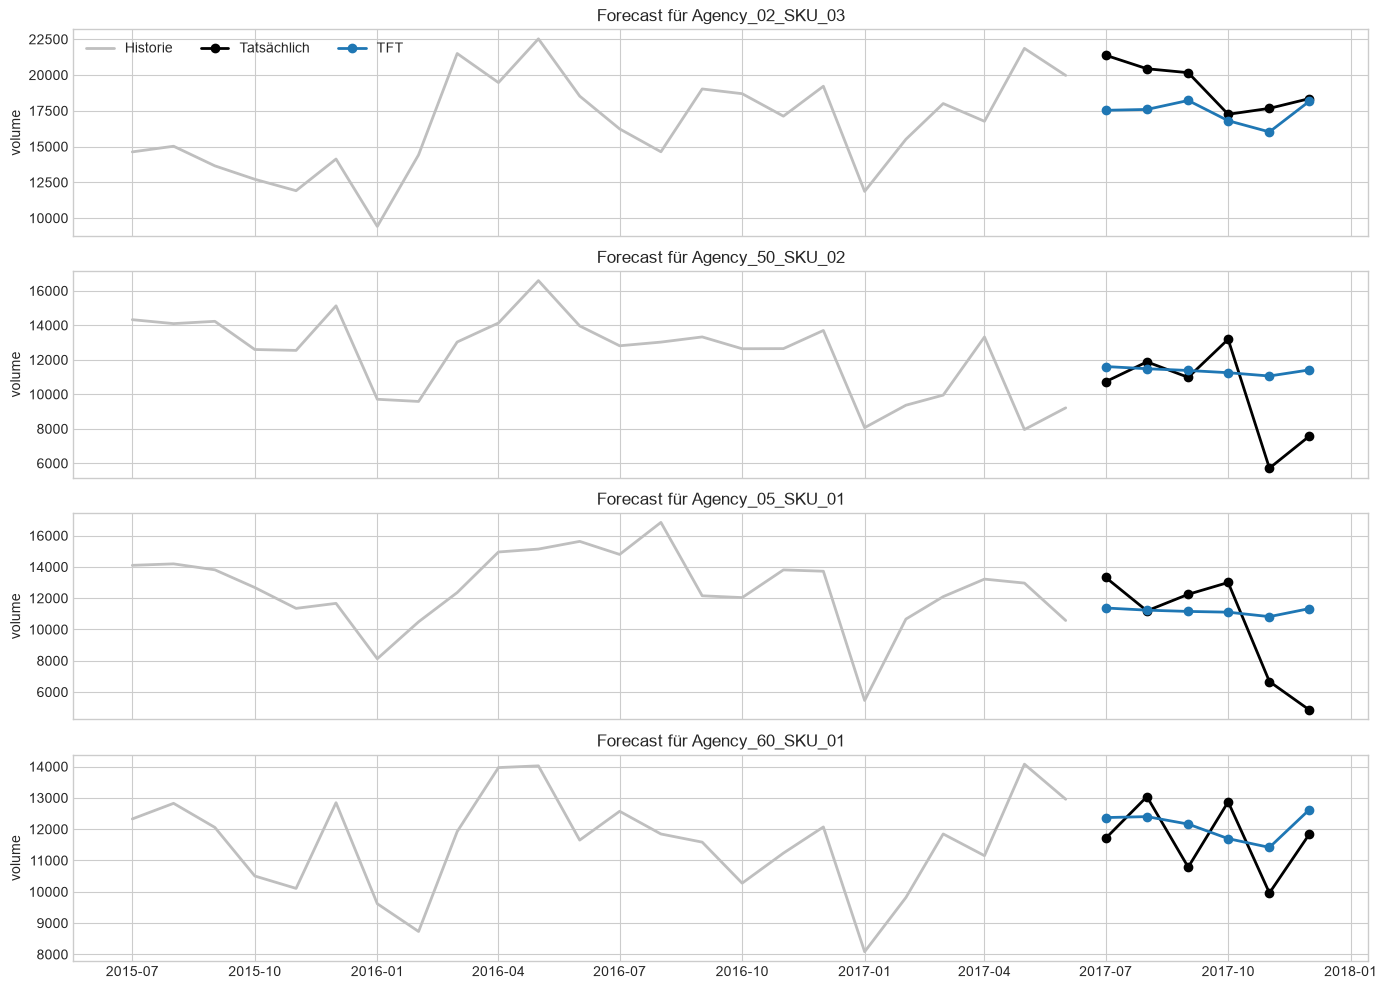

,model,scope,MAE,RMSE,MAPE_%
0,Temporal Fusion Transformer,48 Zeitreihen,1232.6,1681.84,18.62


In [12]:
fig, axes = plt.subplots(len(plot_series), 1, figsize=(14, 10), sharex=True)

for ax, series_id in zip(axes, plot_series):
    forecast_slice = results_df[results_df["series_id"] == series_id].sort_values("time_idx")
    history_start = int(forecast_slice["time_idx"].min()) - encoder_length
    history_slice = model_df[
        (model_df["series_id"] == series_id)
        & (model_df["time_idx"] >= history_start)
        & (model_df["time_idx"] < forecast_slice["time_idx"].min())
    ].sort_values("time_idx")

    ax.plot(history_slice["date"], history_slice["volume"], linewidth=2, color="0.75", label="Historie")
    ax.plot(forecast_slice["date"], forecast_slice["actual"], marker="o", linewidth=2, color="black", label="Tatsächlich")
    
    ax.plot(forecast_slice["date"], forecast_slice["tft_forecast"], marker="o", linewidth=2, color="tab:blue", label="TFT")
    ax.set_title(f"Forecast für {series_id}")
    ax.set_ylabel("volume")

axes[0].legend(ncol=3, loc="upper left")
plt.tight_layout()
plt.show()

metric_df

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


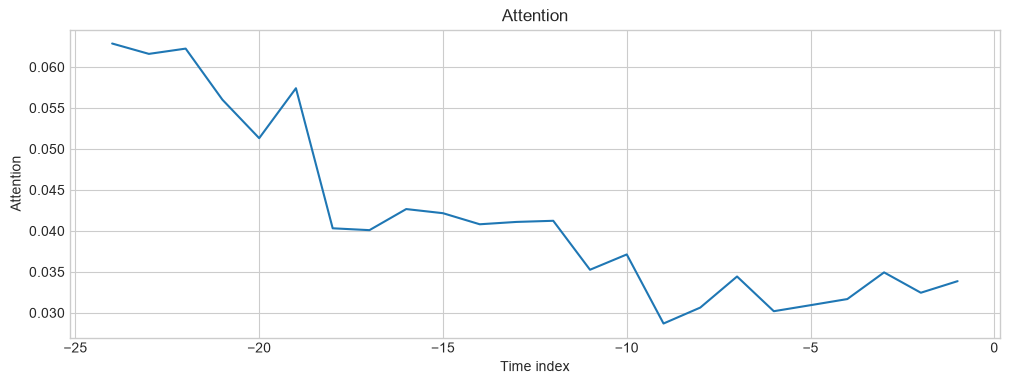

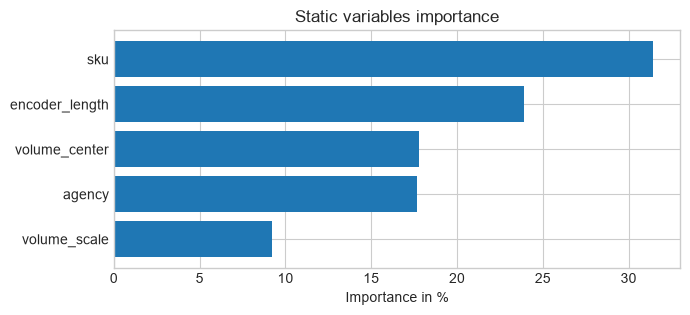

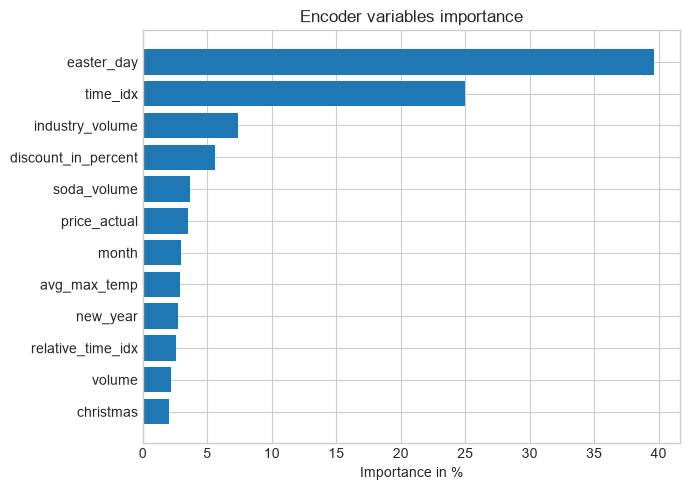

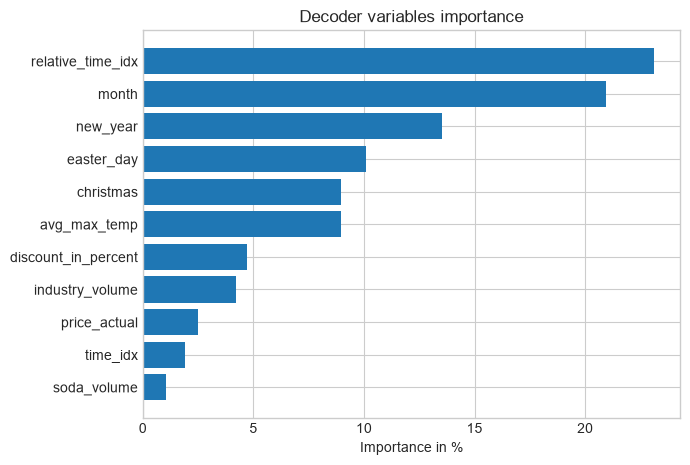

,block,variable,importance_%
0,static,sku,31.42
1,static,encoder_length,23.89
2,static,volume_center,17.81
3,static,agency,17.64
4,static,volume_scale,9.24
5,encoder,easter_day,39.68
6,encoder,time_idx,24.95
7,encoder,industry_volume,7.35
8,encoder,discount_in_percent,5.56
9,encoder,soda_volume,3.62


In [13]:
raw_prediction_output = tft.predict(
    val_tft_loader,
    mode="raw",
    trainer_kwargs={"accelerator": "cpu", "devices": 1},
    return_index=True,
)

interpretation = tft.interpret_output(raw_prediction_output.output, reduction="sum")
interpretation_figs = tft.plot_interpretation(interpretation)

for plot_name in ["attention", "static_variables", "encoder_variables", "decoder_variables"]:
    display(interpretation_figs[plot_name])
    plt.close(interpretation_figs[plot_name])


def importance_table(values, labels, block_name):
    weights = values.detach().cpu().numpy().astype(float)
    weights = weights / weights.sum()
    return pd.DataFrame(
        {
            "block": block_name,
            "variable": list(labels),
            "importance_%": np.round(weights * 100, 2),
        }
    ).sort_values("importance_%", ascending=False)


importance_df = pd.concat(
    [
        importance_table(interpretation["static_variables"], tft.static_variables, "static"),
        importance_table(interpretation["encoder_variables"], tft.encoder_variables, "encoder"),
        importance_table(interpretation["decoder_variables"], tft.decoder_variables, "decoder"),
    ],
    ignore_index=True,
)
importance_df

# Ensemble Training

In [14]:
def predict_matrices(model):
    """Vorhersagen eines Modells über den Validierungssplit als numpy-Matrizen."""
    output = model.predict(
        val_tft_loader,
        trainer_kwargs={"accelerator": "cpu", "devices": 1},
        return_index=True,
        return_x=True,
        return_y=True,
    )
    pred_matrix = output.output.detach().cpu().numpy()
    actual_matrix = output.y[0].detach().cpu().numpy()
    time_matrix = output.x["decoder_time_idx"].detach().cpu().numpy()
    return pred_matrix, actual_matrix, time_matrix, output.index


def build_results(pred_matrix, actual_matrix, time_matrix, index_df, forecast_col):
    """Aus den Matrizen einen langen Ergebnis-DataFrame mit Datum bauen."""
    rows = []
    for row_idx in range(pred_matrix.shape[0]):
        agency = index_df.iloc[row_idx]["agency"]
        sku = index_df.iloc[row_idx]["sku"]
        series_id = f"{agency}_{sku}"
        for step_idx in range(pred_matrix.shape[1]):
            rows.append(
                {
                    "agency": agency,
                    "sku": sku,
                    "series_id": series_id,
                    "time_idx": int(time_matrix[row_idx, step_idx]),
                    "actual": float(actual_matrix[row_idx, step_idx]),
                    forecast_col: float(pred_matrix[row_idx, step_idx]),
                }
            )
    return pd.DataFrame(rows).merge(
        model_df[["series_id", "agency", "sku", "time_idx", "date"]],
        on=["series_id", "agency", "sku", "time_idx"],
        how="left",
    )

In [15]:
from lightning.pytorch.callbacks import EarlyStopping

def train_tuned_tft(seed):
    L.seed_everything(seed, verbose=False)
    np.random.seed(seed)
    torch.manual_seed(seed)

    model = TemporalFusionTransformer.from_dataset(
        training,
        learning_rate=0.03,
        hidden_size=16,
        attention_head_size=4,
        dropout=0.1,
        hidden_continuous_size=8,
        output_size=7,
        loss=QuantileLoss(),
        log_interval=-1,
        reduce_on_plateau_patience=2,
    )
    trainer = L.Trainer(
        default_root_dir=f"/tmp/tft_tuned_{seed}",
        max_epochs=40,
        accelerator="cpu",
        devices=1,
        logger=False,
        enable_checkpointing=False,
        enable_model_summary=False,
        enable_progress_bar=False,
        gradient_clip_val=0.1,
        callbacks=[EarlyStopping(monitor="val_loss", patience=6, mode="min")],
    )
    trainer.fit(model, train_dataloaders=train_tft_loader, val_dataloaders=val_tft_loader)
    return model, trainer.current_epoch

In [30]:
ensemble_seeds = [4, 5, 6] 
models = []

for seed in ensemble_seeds:
    model, epochs_run = train_tuned_tft(seed)
    models.append(model)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud log

In [31]:
tuned_pred_list = []
tuned_actual = tuned_time = tuned_index = None
single_maes = []

for seed, model in zip(ensemble_seeds, models):
    pred_m, actual_m, time_m, index_df = predict_matrices(model)
    if tuned_actual is None:
        tuned_actual, tuned_time, tuned_index = actual_m, time_m, index_df
    else:
        # Ensemble-Mittelung in Schritt 3 setzt identische Zeilenreihenfolge aller Modelle voraus.
        #
        assert index_df.equals(tuned_index), "Reihenfolge der Vorhersagen weicht zwischen Modellen ab!"
    tuned_pred_list.append(pred_m)
    single_maes.append(round(float(mae(actual_m, pred_m)), 1))

print("MAE je Seed:", single_maes)



GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with 

MAE je Seed: [1231.5, 1279.9, 1212.8]


In [32]:
ensemble_pred = np.mean(np.stack(tuned_pred_list, axis=0), axis=0)
ensemble_results = build_results(ensemble_pred, tuned_actual, tuned_time, tuned_index, "ensemble")
print("Ensemble MAE:", round(mae(ensemble_results["actual"], ensemble_results["ensemble"]), 1))

Ensemble MAE: 1199.7
